# Liver Disease — Exploratory Data Analysis
Dataset: ILPD (Indian Liver Patient Dataset).

Note on the target column: in the original ILPD dataset,
`Dataset` = 1 means liver disease present, and 2 means no
disease. We'll remap this to the usual 1/0 in preprocessing.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline


## 1. Load the dataset
Columns: Age, Gender, Total_Bilirubin, Direct_Bilirubin,
Alkaline_Phosphotase, Alamine_Aminotransferase,
Aspartate_Aminotransferase, Total_Protiens, Albumin,
Albumin_and_Globulin_Ratio, Dataset (target)

In [8]:
df = pd.read_csv("../../data/raw/liver_disease.csv")
df = df.rename(columns={
    "age": "Age",
    "gender": "Gender",
    "tot_bilirubin": "Total_Bilirubin",
    "direct_bilirubin": "Direct_Bilirubin",
    "tot_proteins": "Total_Protiens",
    "albumin": "Albumin",
    "ag_ratio": "Albumin_and_Globulin_Ratio",
    "sgpt": "Alamine_Aminotransferase",
    "sgot": "Aspartate_Aminotransferase",
    "alkphos": "Alkaline_Phosphotase",
    "is_patient": "Dataset",
})
df.head()


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Alamine_Aminotransferase,Aspartate_Aminotransferase,Alkaline_Phosphotase,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## 2. Basic info

In [9]:
print("Shape:", df.shape)
df.info()


Shape: (583, 11)
<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Total_Protiens              583 non-null    int64  
 5   Albumin                     583 non-null    int64  
 6   Albumin_and_Globulin_Ratio  583 non-null    int64  
 7   Alamine_Aminotransferase    583 non-null    float64
 8   Aspartate_Aminotransferase  583 non-null    float64
 9   Alkaline_Phosphotase        579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 50.2 KB


## 3. Check for missing values
`Albumin_and_Globulin_Ratio` commonly has a few missing
values in this dataset.

In [10]:
df.isnull().sum()


Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Alkaline_Phosphotase          4
Dataset                       0
dtype: int64

## 4. Class balance

Dataset
1    416
2    167
Name: count, dtype: int64


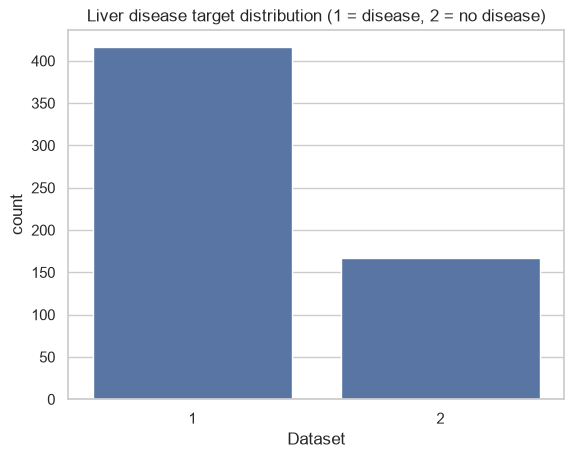

In [11]:
print(df["Dataset"].value_counts())

sns.countplot(x="Dataset", data=df)
plt.title("Liver disease target distribution (1 = disease, 2 = no disease)")
plt.show()


## 5. Gender distribution
This dataset is known to be imbalanced by gender — worth
noting in your report as a limitation.

Gender
Male      441
Female    142
Name: count, dtype: int64


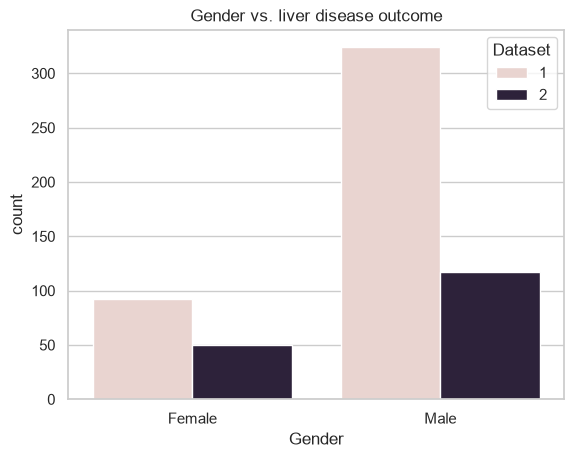

In [12]:
print(df["Gender"].value_counts())
sns.countplot(x="Gender", hue="Dataset", data=df)
plt.title("Gender vs. liver disease outcome")
plt.show()


## 6. Feature distributions

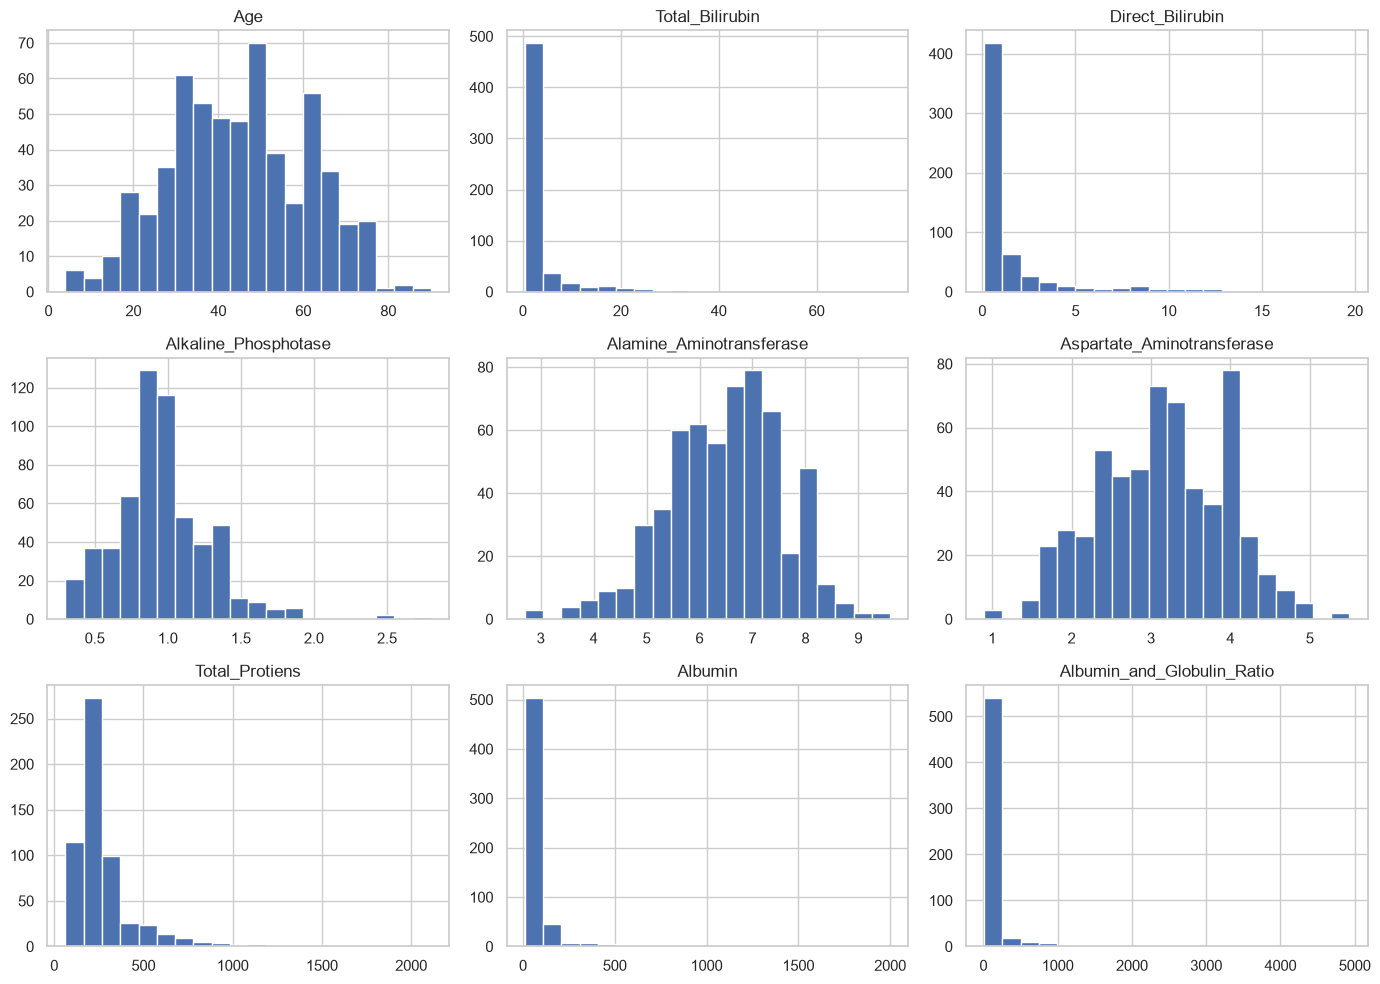

In [13]:
numeric_cols = ["Age", "Total_Bilirubin", "Direct_Bilirubin",
                "Alkaline_Phosphotase", "Alamine_Aminotransferase",
                "Aspartate_Aminotransferase", "Total_Protiens",
                "Albumin", "Albumin_and_Globulin_Ratio"]

df[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()


## 7. Correlation heatmap

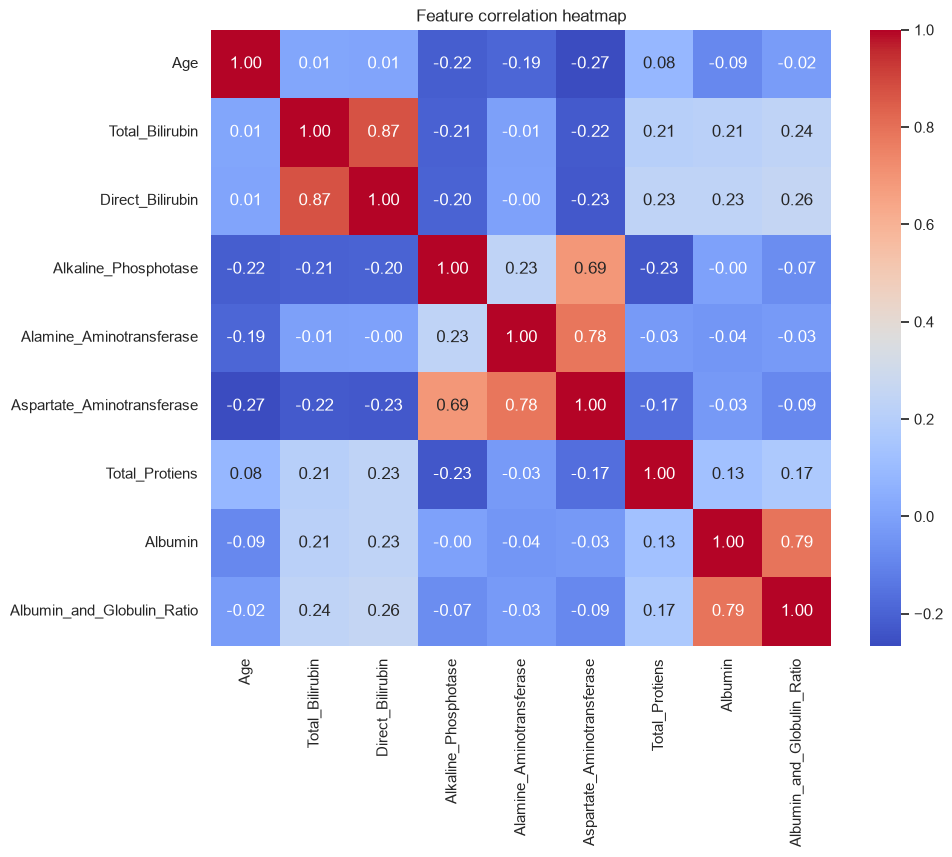

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature correlation heatmap")
plt.show()


## Notes / takeaways
_Write down what you notice here before moving to preprocessing._